# T10 Leakage-Safe Hyperparameter Tuning

T10 tunes the four existing T09 model families with Train-only, date-aware expanding-window cross-validation. Each fold fits T08 preprocessing only on its fold-training rows. Selected configurations are refitted on complete Train and evaluated once on Validation. Test is not evaluated, and this task performs no resampling, feature selection, threshold optimization, or final-model selection.

In [1]:
from pathlib import Path
from time import perf_counter
import hashlib
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data' / 'raw' / 'weatherAUS.csv').is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from fdm_rainfall.data import load_weather_data, chronological_train_validation_test_split
from fdm_rainfall.modeling import MODEL_NAMES
from fdm_rainfall.tuning import (
    best_parameter_table, build_tuning_configurations, compare_baseline_and_tuned,
    cv_fold_boundary_table, date_aware_expanding_window_splits,
    fit_and_evaluate_tuned_models, prepare_cv_folds,
    prepare_engineered_train_validation, run_tuning_search,
    save_tuned_figures, tuning_configuration_table,
)

DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'weatherAUS.csv'
TABLE_DIR = PROJECT_ROOT / 'reports' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'hyperparameter_tuning'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
EXPECTED_SHA256 = '573FD715CD69FCACC4DF32024D823B450AE3EDAAE7E8FF2EEB623ADBED424014'
pd.set_option('display.max_columns', 30)
pd.set_option('display.precision', 6)

## Data boundary and why chronological CV is required

Weather observations are time ordered, so shuffled K-fold validation could train on later weather and score earlier weather. T10 therefore uses three expanding windows over unique Train dates. Splitting unique dates first ensures that the multiple locations observed on a calendar date never cross a fold boundary. The outer Validation and Test periods remain outside tuning.

In [2]:
raw_checksum = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest().upper()
assert raw_checksum == EXPECTED_SHA256
raw = load_weather_data(DATA_PATH)
split = chronological_train_validation_test_split(raw)
assert [len(split.train), len(split.validation), len(split.test)] == [99_546, 21_342, 21_305]
display(split.summary)
print('Raw SHA-256:', raw_checksum)

,Split,First date,Last date,Rows,Percentage of labelled rows,Unique dates,Locations,RainTomorrow No count,RainTomorrow Yes count,Yes percentage,Missing target count
0,Train,2007-11-01,2015-01-12,99546,70.007666,2541,49,77087,22459,22.561429,0
1,Validation,2015-01-13,2016-04-08,21342,15.009178,452,48,16990,4352,20.391716,0
2,Test,2016-04-09,2017-06-25,21305,14.983157,443,49,16239,5066,23.778456,0


Raw SHA-256: 573FD715CD69FCACC4DF32024D823B450AE3EDAAE7E8FF2EEB623ADBED424014


## Exact Train-only expanding-window folds

`TimeSeriesSplit` is applied to ordered unique Train dates—not raw rows. The resulting date blocks are mapped back to all source rows. Every fold must have zero row overlap, zero date overlap, and a strictly earlier fold-training maximum date than fold-validation minimum date.

In [3]:
folds = date_aware_expanding_window_splits(split.train['Date'], n_splits=3)
fold_boundaries = cv_fold_boundary_table(split.train['Date'], folds)
assert fold_boundaries['Strict chronology'].all()
assert (fold_boundaries[['Row overlap', 'Date overlap']] == 0).all().all()
fold_boundaries.to_csv(TABLE_DIR / '10_cv_fold_boundaries.csv', index=False)
display(fold_boundaries)

,Fold,Train first date,Train last date,Validation first date,Validation last date,Train rows,Validation rows,Train unique dates,Validation unique dates,Row overlap,Date overlap,Strict chronology
0,1,2007-11-01,2009-07-28,2009-07-29,2011-05-24,11819,28665,636,635,0,0,True
1,2,2007-11-01,2011-05-24,2011-05-25,2013-04-17,40484,28720,1271,635,0,0,True
2,3,2007-11-01,2013-04-17,2013-04-18,2015-01-12,69204,30342,1906,635,0,0,True


## Leakage-safe fold preprocessing

For each fold the order is raw fold-train → default T08 feature engineering → fit imputation/encoding/scaling on fold-train → transform fold-validation. Fold preprocessing is cached only after being fitted on that fold's training rows, so candidates share safe matrices without allowing later Train-period observations to influence earlier folds. Logistic Regression uses scaled folds; the tree and ensemble families use unscaled folds.

In [4]:
fold_preprocessing_start = perf_counter()
scaled_cv_folds = prepare_cv_folds(split.train, folds, scale_numeric=True)
unscaled_cv_folds = prepare_cv_folds(split.train, folds, scale_numeric=False)
fold_preprocessing_seconds = perf_counter() - fold_preprocessing_start
for definition, scaled_fold, unscaled_fold in zip(folds, scaled_cv_folds, unscaled_cv_folds, strict=True):
    assert scaled_fold.preprocessor.fit_row_count_ == len(definition.train_positions)
    assert unscaled_fold.preprocessor.fit_row_count_ == len(definition.train_positions)
    assert scaled_fold.dates_train.max() < scaled_fold.dates_validation.min()
    assert unscaled_fold.dates_train.max() < unscaled_fold.dates_validation.min()
print(f'Prepared six fold representations in {fold_preprocessing_seconds:.3f} seconds')

Prepared six fold representations in 1.792 seconds


## Primary metric and bounded search spaces

Average Precision (PR-AUC) is the sole performance metric used for candidate selection because `RainTomorrow=Yes` is the minority and operationally important class. ROC-AUC, Yes-class F1/recall, and balanced accuracy are retained for interpretation only. Exact mean PR-AUC ties use original candidate order as a neutral deterministic tie-break; none of the current winners required it. Logistic Regression uses a compact exhaustive grid. The larger tree and ensemble spaces use deterministic bounded sampling with `random_state=42`. A custom candidate loop is used instead of preprocessing all Train rows before a built-in CV search.

In [5]:
configurations = build_tuning_configurations()
configuration_table = tuning_configuration_table(n_splits=3)
configuration_table.to_csv(TABLE_DIR / '10_search_configurations.csv', index=False)
display(configuration_table)
print('Total candidate configurations:', int(configuration_table['Candidates'].sum()))
print('Total Train-CV model fits:', int(configuration_table['Model fits'].sum()))

,Model,Representation,Search method,Primary metric,Candidates,CV folds,Model fits,Parameter space
0,Logistic Regression,"T08 engineered, scaled",Exhaustive grid,Average Precision (PR-AUC),8,3,24,"{""C"":[0.01,0.1,1.0,10.0],""class_weight"":[null,..."
1,Decision Tree,"T08 engineered, unscaled",Deterministic randomized,Average Precision (PR-AUC),12,3,36,"{""class_weight"":[null,""balanced""],""criterion"":..."
2,Random Forest,"T08 engineered, unscaled",Deterministic randomized,Average Precision (PR-AUC),8,3,24,"{""class_weight"":[null,""balanced""],""max_depth"":..."
3,Gradient Boosting,"T08 engineered, unscaled",Deterministic randomized,Average Precision (PR-AUC),6,3,18,"{""learning_rate"":[0.03,0.05,0.1],""max_depth"":[..."


Total candidate configurations: 34
Total Train-CV model fits: 102


## Tune all four existing model families

Each candidate is fitted independently in all three folds. Candidate selection never accesses outer Validation or Test. Search sizes are intentionally bounded for a student machine while covering regularization/class weighting, tree complexity, bagging configuration, and boosting learning-rate/complexity trade-offs.

In [6]:
search_results = {}
for model_name in MODEL_NAMES:
    configuration = configurations[model_name]
    prepared = scaled_cv_folds if configuration.scale_numeric else unscaled_cv_folds
    print(f'Searching {model_name}: {len(configuration_table.loc[configuration_table.Model == model_name]) and configuration_table.loc[configuration_table.Model == model_name, "Candidates"].iloc[0]} candidates')
    search_results[model_name] = run_tuning_search(configuration, prepared)
    print(f'  completed in {search_results[model_name].runtime_seconds:.3f} seconds')

cv_fold_results = pd.concat(
    [result.fold_results for result in search_results.values()], ignore_index=True
)
cv_summary = pd.concat(
    [result.summary.assign(Model=model_name) for model_name, result in search_results.items()],
    ignore_index=True,
).loc[:, ['Model', *search_results['Logistic Regression'].summary.columns]]
best_parameters_table = best_parameter_table(search_results)
cv_fold_results.to_csv(TABLE_DIR / '10_cv_fold_results.csv', index=False)
cv_summary.to_csv(TABLE_DIR / '10_cv_candidate_summary.csv', index=False)
best_parameters_table.to_csv(TABLE_DIR / '10_best_hyperparameters.csv', index=False)
display(best_parameters_table)

Searching Logistic Regression: 8 candidates


  completed in 10.821 seconds
Searching Decision Tree: 12 candidates


  completed in 21.009 seconds
Searching Random Forest: 8 candidates


  completed in 55.149 seconds
Searching Gradient Boosting: 6 candidates


  completed in 96.338 seconds


,Model,Best parameters,Best CV PR-AUC mean,Best CV PR-AUC std,Candidates,CV folds,Model fits,Search method,Search runtime seconds
0,Logistic Regression,"{""C"":0.1,""class_weight"":null}",0.707032,0.003944,8,3,24,Exhaustive grid,10.820740
1,Decision Tree,"{""class_weight"":""balanced"",""criterion"":""gini"",...",0.640795,0.015415,12,3,36,Deterministic randomized,21.008859
2,Random Forest,"{""class_weight"":null,""max_depth"":20,""max_featu...",0.722824,0.008788,8,3,24,Deterministic randomized,55.148940
3,Gradient Boosting,"{""learning_rate"":0.1,""max_depth"":3,""min_sample...",0.721177,0.002886,6,3,18,Deterministic randomized,96.338432


## Refit selected configurations and evaluate Validation once

After Train-only selection, two fresh preprocessors are fitted on complete Train: scaled for Logistic Regression and unscaled for the other three families. Each selected estimator is then fitted on complete Train and evaluated once on the untouched development Validation set at its default classification threshold.

In [7]:
final_preprocessing_start = perf_counter()
scaled_train_validation = prepare_engineered_train_validation(
    split.train, split.validation, scale_numeric=True
)
unscaled_train_validation = prepare_engineered_train_validation(
    split.train, split.validation, scale_numeric=False
)
final_preprocessing_seconds = perf_counter() - final_preprocessing_start
assert scaled_train_validation.X_train.shape == (99_546, 89)
assert scaled_train_validation.X_validation.shape == (21_342, 89)
assert unscaled_train_validation.X_train.shape == (99_546, 89)
assert unscaled_train_validation.X_validation.shape == (21_342, 89)
best_parameters = {name: result.best_parameters for name, result in search_results.items()}
tuned_evaluation = fit_and_evaluate_tuned_models(
    best_parameters, scaled_train_validation, unscaled_train_validation
)
tuned_metrics = tuned_evaluation.comparison.copy()
tuned_metrics.to_csv(TABLE_DIR / '10_tuned_validation_metrics.csv', index=False)
tuned_metrics[['Model', 'TN', 'FP', 'FN', 'TP']].to_csv(
    TABLE_DIR / '10_tuned_validation_confusion_counts.csv', index=False
)
tuned_evaluation.execution_times.to_csv(
    TABLE_DIR / '10_final_fit_times.csv', index=False
)
display(tuned_metrics.style.format({column: '{:.6f}' for column in tuned_metrics.columns[1:8]}))

,Model,Accuracy,Balanced Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Logistic Regression,0.854934,0.704893,0.734854,0.451517,0.559351,0.869321,0.677184,16281,709,2387,1965
1,Decision Tree,0.800768,0.768042,0.508191,0.712776,0.593344,0.844848,0.635289,13988,3002,1250,3102
2,Random Forest,0.859385,0.700083,0.781341,0.431066,0.555605,0.883234,0.704679,16465,525,2476,1876
3,Gradient Boosting,0.856714,0.704473,0.748846,0.447381,0.560127,0.875352,0.692540,16337,653,2405,1947


## T09 baseline versus T10 tuned Validation results

Every tuned model is compared only with its own established T09 baseline. Changes are arithmetic tuned-minus-baseline differences, not evidence of statistical significance. Metric leaders and improvements are descriptive and do not constitute final-model selection.

In [8]:
baseline_metrics = pd.read_csv(TABLE_DIR / '09_validation_baseline_comparison.csv')
baseline_snapshot = baseline_metrics.copy(deep=True)
baseline_vs_tuned = compare_baseline_and_tuned(baseline_metrics, tuned_metrics)
pd.testing.assert_frame_equal(baseline_metrics, baseline_snapshot)
baseline_vs_tuned.to_csv(TABLE_DIR / '10_baseline_vs_tuned_validation.csv', index=False)
display(baseline_vs_tuned.style.format({column: '{:+.6f}' if column.startswith('Change ') else '{:.6f}' for column in baseline_vs_tuned.columns[1:]}))

,Model,Baseline Accuracy,Tuned Accuracy,Change Accuracy,Baseline Balanced Accuracy,Tuned Balanced Accuracy,Change Balanced Accuracy,Baseline Precision (Yes),Tuned Precision (Yes),Change Precision (Yes),Baseline Recall (Yes),Tuned Recall (Yes),Change Recall (Yes),Baseline F1 (Yes),Tuned F1 (Yes),Change F1 (Yes),Baseline ROC-AUC,Tuned ROC-AUC,Change ROC-AUC,Baseline PR-AUC,Tuned PR-AUC,Change PR-AUC
0,Logistic Regression,0.855028,0.854934,-0.000094,0.705294,0.704893,-0.000401,0.734701,0.734854,+0.000153,0.452436,0.451517,-0.000919,0.560011,0.559351,-0.000660,0.868953,0.869321,+0.000368,0.676829,0.677184,+0.000354
1,Decision Tree,0.793225,0.800768,+0.007544,0.686902,0.768042,+0.081140,0.493187,0.508191,+0.015004,0.507353,0.712776,+0.205423,0.500170,0.593344,+0.093174,0.686902,0.844848,+0.157946,0.350679,0.635289,+0.284610
2,Random Forest,0.860416,0.859385,-0.001031,0.703721,0.700083,-0.003639,0.780318,0.781341,+0.001023,0.439108,0.431066,-0.008042,0.561976,0.555605,-0.006371,0.880655,0.883234,+0.002579,0.700227,0.704679,+0.004452
3,Gradient Boosting,0.857136,0.856714,-0.000422,0.705336,0.704473,-0.000863,0.750096,0.748846,-0.001250,0.448989,0.447381,-0.001608,0.561736,0.560127,-0.001610,0.873906,0.875352,+0.001446,0.690868,0.692540,+0.001672


## Validation-only figures

The following figures show tuned Validation confusion matrices, combined ROC curves, combined Precision–Recall curves, and baseline-versus-tuned Validation metrics. No Test result is plotted.

reports\figures\hyperparameter_tuning\10_tuned_validation_confusion_matrices.png


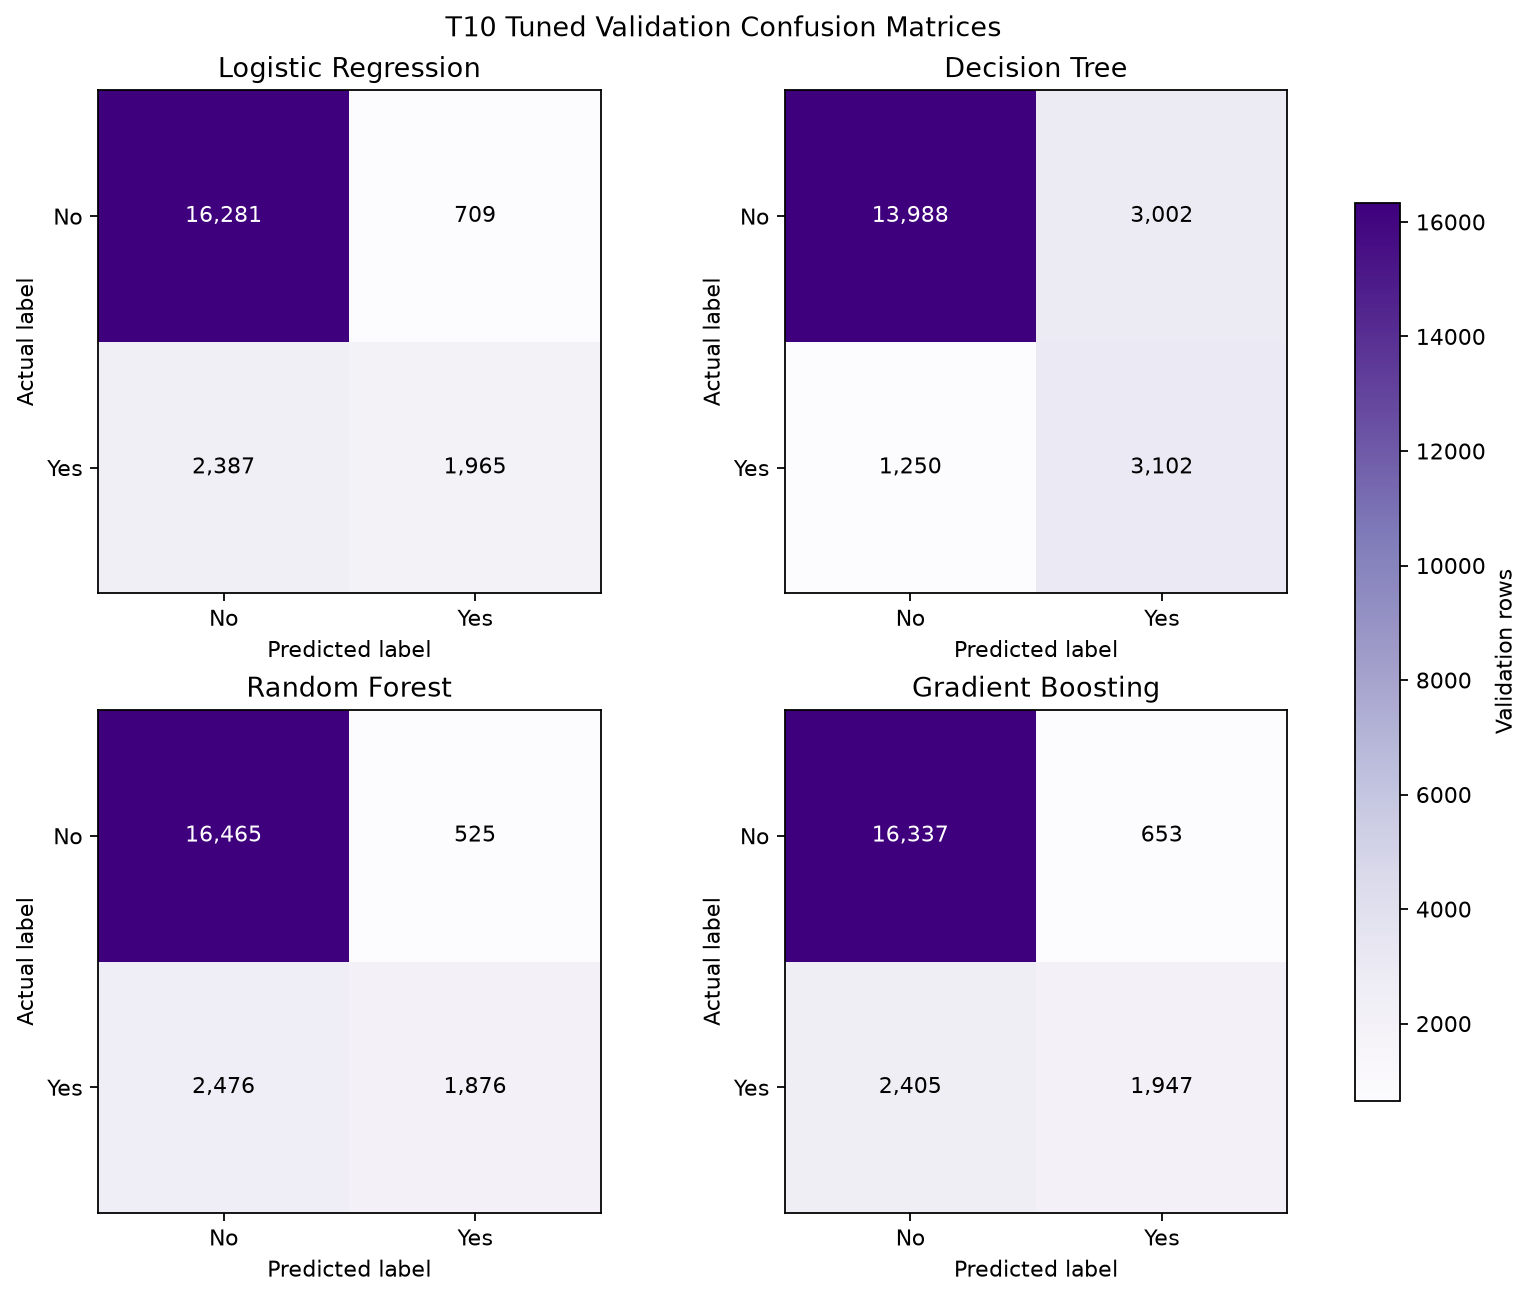

reports\figures\hyperparameter_tuning\10_tuned_validation_roc_curves.png


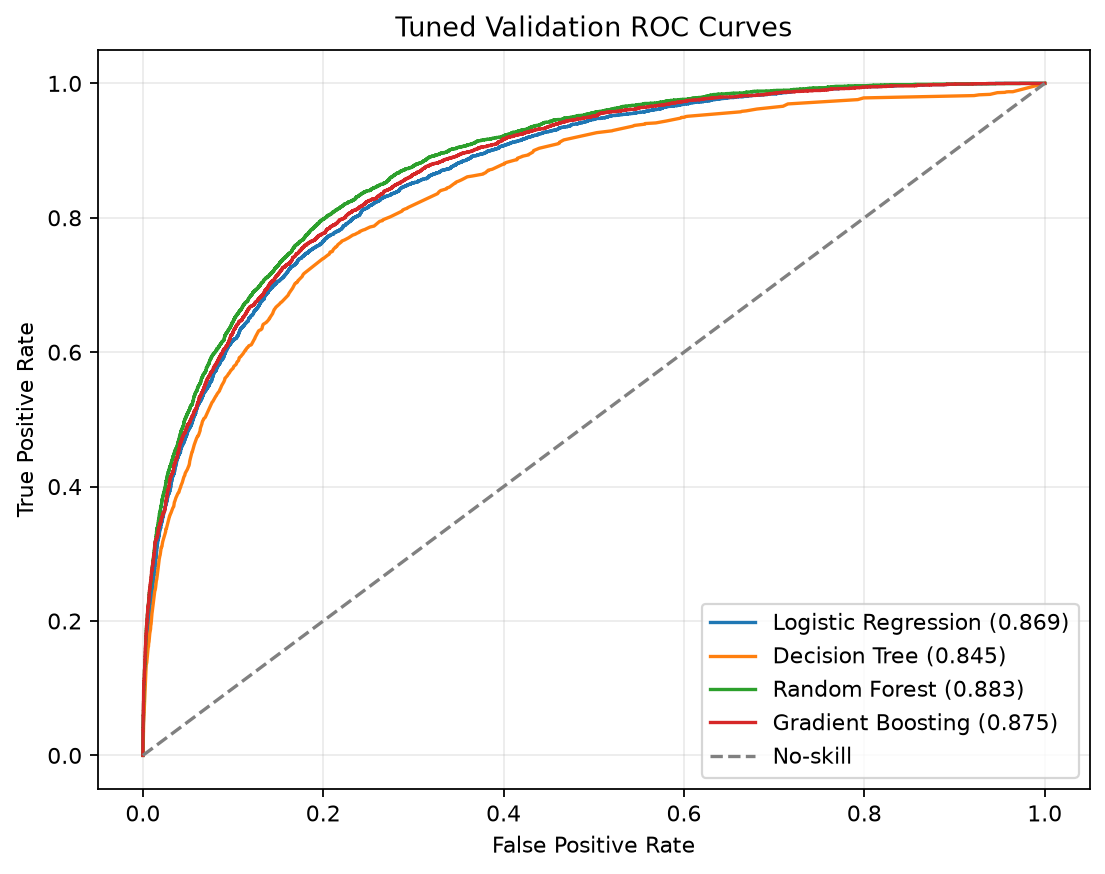

reports\figures\hyperparameter_tuning\10_tuned_validation_precision_recall_curves.png


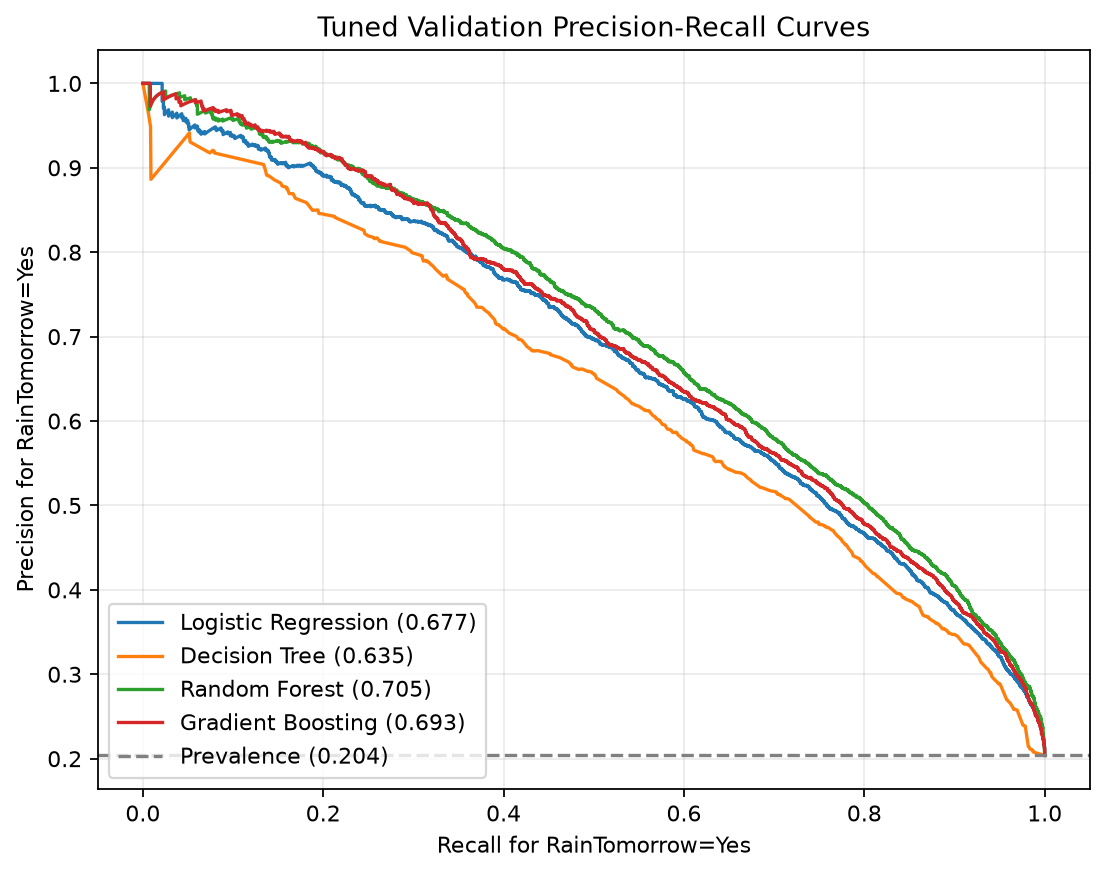

reports\figures\hyperparameter_tuning\10_baseline_vs_tuned_validation_metrics.png


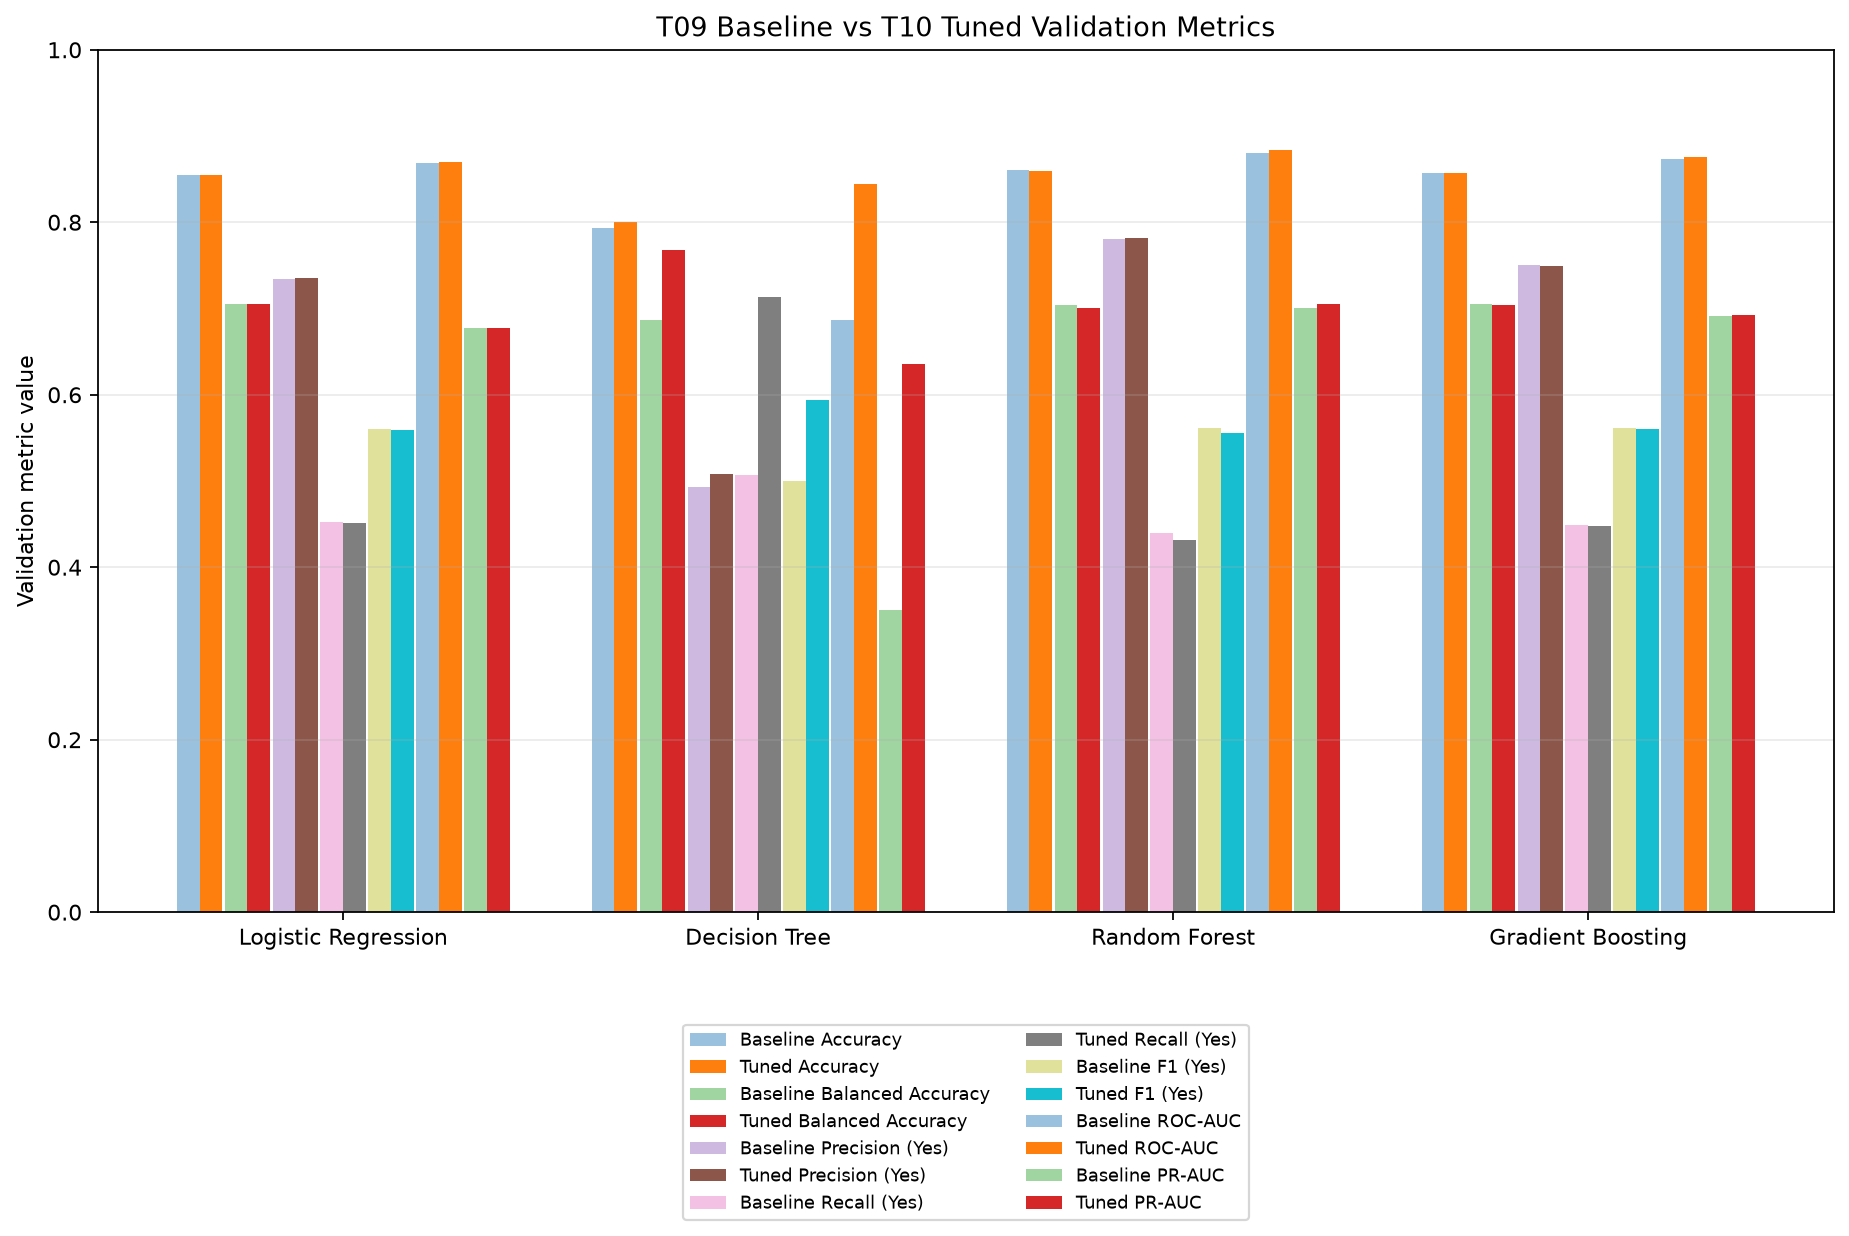

In [9]:
figure_paths = save_tuned_figures(
    tuned_evaluation,
    unscaled_train_validation.y_validation,
    baseline_metrics,
    FIGURE_DIR,
)
for figure_path in figure_paths:
    print(figure_path.relative_to(PROJECT_ROOT))
    display(Image(filename=str(figure_path)))

## Runtime and interpretation

Search results must be interpreted as time-aware Train-CV evidence followed by one outer Validation check. A higher Train-CV or Validation metric does not prove a universally better model, and small changes may be noise or period-specific. Class weighting can change the default-threshold precision/recall balance, while tree depth, leaf constraints, ensemble size, and boosting learning rate regulate complexity.

In [10]:
runtime_rows = [
    {'Stage': 'Fold preprocessing (scaled + unscaled)', 'Seconds': fold_preprocessing_seconds},
    *[{'Stage': f'{name} Train-CV search', 'Seconds': result.runtime_seconds} for name, result in search_results.items()],
    {'Stage': 'Complete Train preprocessing (scaled + unscaled)', 'Seconds': final_preprocessing_seconds},
]
runtime_table = pd.DataFrame(runtime_rows)
runtime_table.loc[len(runtime_table)] = {
    'Stage': 'Total preprocessing and search',
    'Seconds': runtime_table['Seconds'].sum(),
}
runtime_table.to_csv(TABLE_DIR / '10_runtime_summary.csv', index=False)
display(runtime_table)
for model_name in MODEL_NAMES:
    pr_change = baseline_vs_tuned.loc[baseline_vs_tuned.Model == model_name, 'Change PR-AUC'].iloc[0]
    recall_change = baseline_vs_tuned.loc[baseline_vs_tuned.Model == model_name, 'Change Recall (Yes)'].iloc[0]
    print(f'{model_name}: Validation PR-AUC change {pr_change:+.6f}; Recall change {recall_change:+.6f}')
print('No final model is selected in T10.')

,Stage,Seconds
0,Fold preprocessing (scaled + unscaled),1.791939
1,Logistic Regression Train-CV search,10.820740
2,Decision Tree Train-CV search,21.008859
3,Random Forest Train-CV search,55.148940
4,Gradient Boosting Train-CV search,96.338432
5,Complete Train preprocessing (scaled + unscaled),0.981740
6,Total preprocessing and search,186.090650


Logistic Regression: Validation PR-AUC change +0.000354; Recall change -0.000919
Decision Tree: Validation PR-AUC change +0.284610; Recall change +0.205423
Random Forest: Validation PR-AUC change +0.004452; Recall change -0.008042
Gradient Boosting: Validation PR-AUC change +0.001672; Recall change -0.001608
No final model is selected in T10.


## Limitations and explicit T10 boundary

The searches are intentionally bounded rather than exhaustive over every plausible parameter. Three expanding folds estimate temporal robustness within Train but cannot eliminate future distribution shift. No resampling, feature-selection experiment, calibration, probability-threshold optimization, final-model selection, or Test evaluation is performed. Test remains reserved for later work after development decisions are complete, and work stops after T10.

In [11]:
test_evaluated = False
assert test_evaluated is False
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest().upper() == EXPECTED_SHA256
print('T10 boundary confirmed: Test was not evaluated; raw checksum remains unchanged.')

T10 boundary confirmed: Test was not evaluated; raw checksum remains unchanged.
